# My thought process and walkthrough
### Time series forecasting on monthly sea level pressure in Darwin, Australia

This notebook is practice with **ARIMA / SARIMA** models on a long-run climate dataset (`darwin_sea_level_pressure.csv`). Darwin sea level pressure is a classic signal in climate work (it's one half of the SOI / ENSO story), so it's a good real-world series for learning seasonality and autoregressive behavior.

**What I'm trying to do:** load the data, understand the series visually, fit a few models, check residuals, and evaluate forecasts on held-out months.

**Libraries:** pandas, matplotlib, statsmodels (`ARIMA`, `SARIMAX`), sklearn (`mean_squared_error`)

### Load the data and take a first look

Starting by reading the CSV and plotting the series so I can see trend, seasonality, and any obvious gaps.

The file is **wide format** (Year + Jan–Dec columns), so this first load is a rough pass —> I reshape it properly later in the notebook once I realized the index wasn't a clean monthly datetime yet.

Year
1855-01-01   NaN
1856-01-01   NaN
1857-01-01   NaN
1858-01-01   NaN
1859-01-01   NaN
Name: Jan, dtype: float64


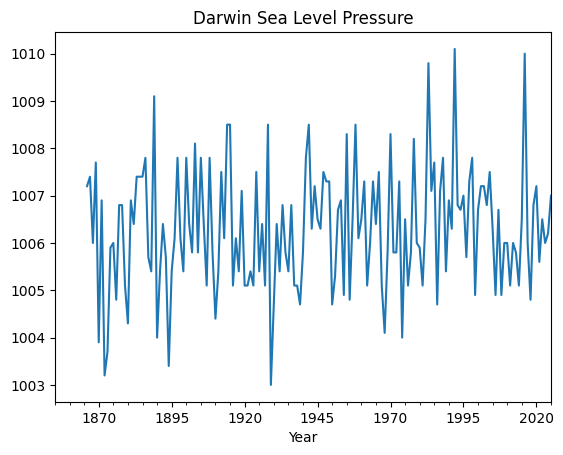

In [1]:
from matplotlib import pyplot as plt
import pandas as pd
import os

# 1. Load the CSV and let Pandas automatically parse the dates
csv_path = "darwin_sea_level_pressure.csv"
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Data file not found: {csv_path}")

series = pd.read_csv(csv_path, header=0, parse_dates=[0], index_col=0)
# If the file loads as a DataFrame, convert to a Series (use the first column)
if isinstance(series, pd.DataFrame):
    series = series.iloc[:, 0].squeeze()

print(series.head())
series.plot(title="Darwin Sea Level Pressure")
plt.show()

### Fit a baseline ARIMA model

**ARIMA(p, d, q)** = autoregressive + differencing + moving average.

- `order=(5, 1, 2)` → AR(5), one difference to help with stationarity, MA(2)
- Using `statsmodels.tsa.arima.model.ARIMA` and checking `.summary()` for coefficients, AIC, etc.

This is exploratory. I haven't tuned (p, d, q) with ACF/PACF or grid search yet, just getting a first fit on the series.

In [2]:
import statsmodels

from statsmodels.tsa.arima.model import ARIMA

# 2. Fit an ARIMA model and show the summary
model = ARIMA(series, order=(5, 1, 2))
model_fit = model.fit()
print(model_fit.summary())

c:\Users\tokri\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\tokri\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\tokri\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                    Jan   No. Observations:                  171
Model:                 ARIMA(5, 1, 2)   Log Likelihood                -275.640
Date:                Tue, 26 May 2026   AIC                            567.281
Time:                        19:35:55   BIC                            592.367
Sample:                    01-01-1855   HQIC                           577.461
                         - 01-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0069      1.911      0.004      0.997      -3.738       3.752
ar.L2         -0.0320      0.089     -0.360      0.719      -0.207       0.143
ar.L3          0.1035      0.104      0.999      0.3

### Residual diagnostics

After fitting, I want to see whether the model left structure on the table:

- **Time plot** of residuals — should look like noise if the model captured the signal
- **KDE / density plot** — roughly centered, not heavily skewed
- **`.describe()`** — quick check on mean (near 0) and spread

If residuals still have patterns, the model order is probably wrong or we need seasonality (SARIMA).

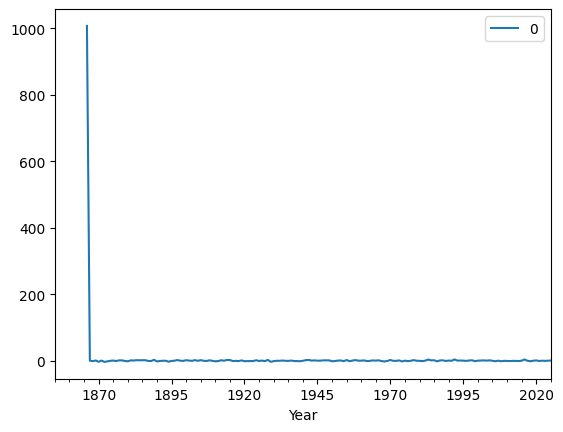

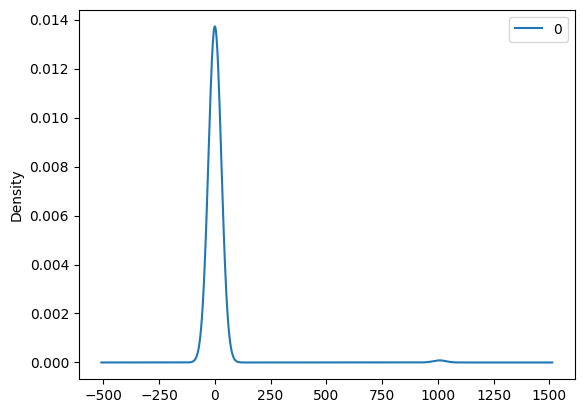

                 0
count   160.000000
mean      6.373512
std      79.630517
min      -3.571333
25%      -0.846972
50%       0.037295
75%       0.984216
max    1007.200000


In [5]:
from pandas import DataFrame
import matplotlib.pyplot as pyplot

residuals = DataFrame(model_fit.resid)
residuals.plot()
pyplot.show()
# density plot of residuals
residuals.plot(kind='kde')
pyplot.show()
# summary stats of residuals
print(residuals.describe())

### Walk-forward validation (rolling one-step forecast)

Train on an initial chunk (~66% of the series), then for each test point:

1. Fit ARIMA on history
2. Forecast one step ahead
3. Append the actual observation to history
4. Repeat

This mimics **real forecasting** — you only know the past when you predict the next month. Using `order=(5, 1, 0)` here, which is slightly different from the earlier fit; still experimental at this stage.

Plot actual vs predicted and compute **RMSE** on the test set.

predicted=1006.864405, expected=1005.100000
predicted=1006.297642, expected=1004.100000
predicted=1006.068547, expected=1005.800000
predicted=1005.694613, expected=1008.300000
predicted=1005.982193, expected=1005.800000
predicted=1006.343533, expected=1005.800000
predicted=1006.158613, expected=1007.300000
predicted=1005.999786, expected=1004.000000
predicted=1006.028382, expected=1006.500000
predicted=1006.510409, expected=1005.100000
predicted=1005.470308, expected=1005.800000
predicted=1005.838569, expected=1008.200000
predicted=1006.071849, expected=1006.000000
predicted=1005.978360, expected=1005.900000
predicted=1006.577764, expected=1005.100000
predicted=1005.808807, expected=1006.500000
predicted=1006.129273, expected=1009.800000
predicted=1006.805108, expected=1007.100000
predicted=1006.821624, expected=1007.700000
predicted=1007.312399, expected=1004.700000
predicted=1006.529768, expected=1007.100000
predicted=1007.219621, expected=1007.800000
predicted=1007.217003, expected=

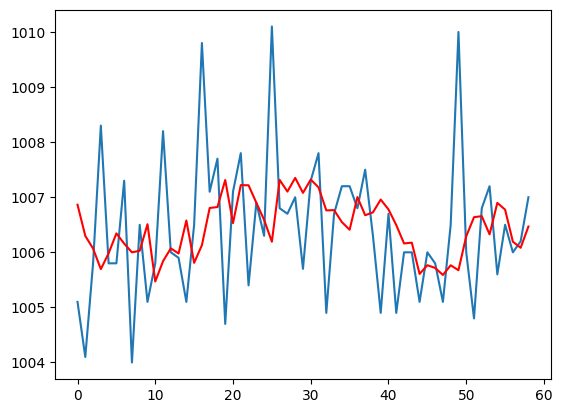

In [6]:
from math import sqrt
from sklearn.metrics import mean_squared_error

X = series.values
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
predictions = list()

for t in range(len(test)):
	model = ARIMA(history, order=(5,1,0))
	model_fit = model.fit()
	output = model_fit.forecast()
	yhat = output[0]
	predictions.append(yhat)
	obs = test[t]
	history.append(obs)
	print('predicted=%f, expected=%f' % (yhat, obs))

rmse = sqrt(mean_squared_error(test, predictions))
print('Test RMSE: %.3f' % rmse)

pyplot.plot(test)
pyplot.plot(predictions, color='red')
pyplot.show()

### Improved pipeline: reshape data + seasonal SARIMA

The wide CSV needed to be melted into a proper **monthly datetime index** before modeling:

- `melt` Year + month columns → long format
- `dropna()` for missing early years
- `pd.to_datetime` + `asfreq("MS")` for monthly start frequency
- Train/test split: **last 150 months** held out

**SARIMAX** adds seasonal terms: `order=(2, 1, 2)`, `seasonal_order=(1, 1, 1, 12)` for monthly seasonality.

This is the version I'd trust more — correct index, explicit seasonality, cleaner eval split.

Date
1866-01-01    1007.2
1866-02-01    1006.3
1866-03-01    1008.3
1866-04-01    1009.7
1866-05-01    1010.7
Freq: MS, Name: Pressure, dtype: float64
Date
2025-08-01    1013.5
2025-09-01    1012.6
2025-10-01    1010.3
2025-11-01    1007.7
2025-12-01    1006.6
Freq: MS, Name: Pressure, dtype: float64
<MonthBegin>


c:\Users\tokri\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


RMSE: 0.976315298988083


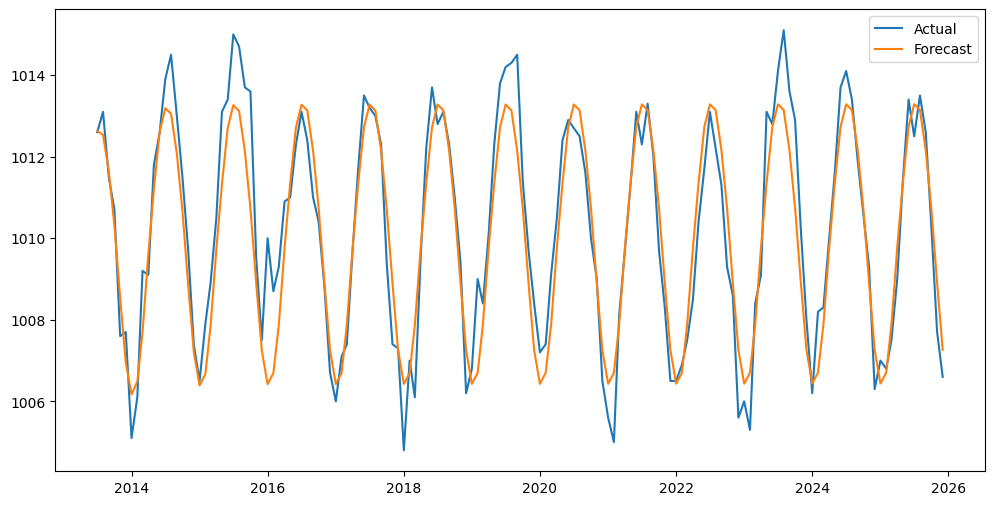

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from math import sqrt

# Load wide CSV: Year, Jan, Feb, ..., Dec
df = pd.read_csv("darwin_sea_level_pressure.csv")

# Convert wide monthly columns into one long monthly time series
series = df.melt(
    id_vars="Year",
    var_name="Month",
    value_name="Pressure"
)

# Drop missing values
series = series.dropna()

# Create monthly datetime index
series["Date"] = pd.to_datetime(
    series["Year"].astype(str) + "-" + series["Month"],
    format="%Y-%b"
)

series = series.sort_values("Date")
series = series.set_index("Date")["Pressure"]

# Force monthly frequency
series = series.asfreq("MS")

print(series.head())
print(series.tail())
print(series.index.freq)

# Train/test split: last 150 months
train = series[:-150]
test = series[-150:]

model = SARIMAX(
    train,
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)

forecast = model_fit.forecast(steps=len(test))

rmse = sqrt(mean_squared_error(test, forecast))
print("RMSE:", rmse)

plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="Forecast")
plt.legend()
plt.show()

### Takeaways

- Wide climate CSVs usually need reshaping before time series work.
- A plain ARIMA can fit, but **seasonal** structure matters for monthly pressure data.
- Always check **residuals** and evaluate on **out-of-sample** data, not just in-sample fit.
- Next steps I'd try: ACF/PACF for order selection, `auto_arima` / grid search, confidence intervals on forecasts.